# 🛒 Análise de Pedidos da Olist

Este projeto de Data Science tem como objetivo analisar dados reais de pedidos de uma plataforma de e-commerce brasileira, focando em:

- Distribuição dos status dos pedidos (entregue, cancelado, etc.)
- Tempo de entrega dos pedidos
- Estatísticas descritivas
- Visualizações gráficas

Os dados utilizados estão disponíveis publicamente no Kaggle:
📎 https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


## 📥 Importação das bibliotecas e leitura dos dados

Importamos as bibliotecas principais (Pandas, Matplotlib, Seaborn) e carregamos o arquivo CSV com os pedidos.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo dos gráficos
sns.set(style="whitegrid")


## 🔍 Análise dos Status dos Pedidos

Vamos verificar quantos pedidos foram entregues, cancelados, ou estão em outros status.


In [4]:
# Lê o arquivo com os dados dos pedidos
df_pedidos = pd.read_csv('olist_orders_dataset.csv')

# Exibe as 5 primeiras linhas
df_pedidos.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
# Contagem de cada status
status_counts = df_pedidos['order_status'].value_counts()

# Exibe os resultados
print(status_counts)


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


## 📊 Visualização dos Status com Gráfico

Aqui criamos um gráfico de barras para visualizar de forma clara a distribuição dos status dos pedidos.


C:\Users\User\AppData\Local\Temp\ipykernel_10056\1868318263.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette="viridis")


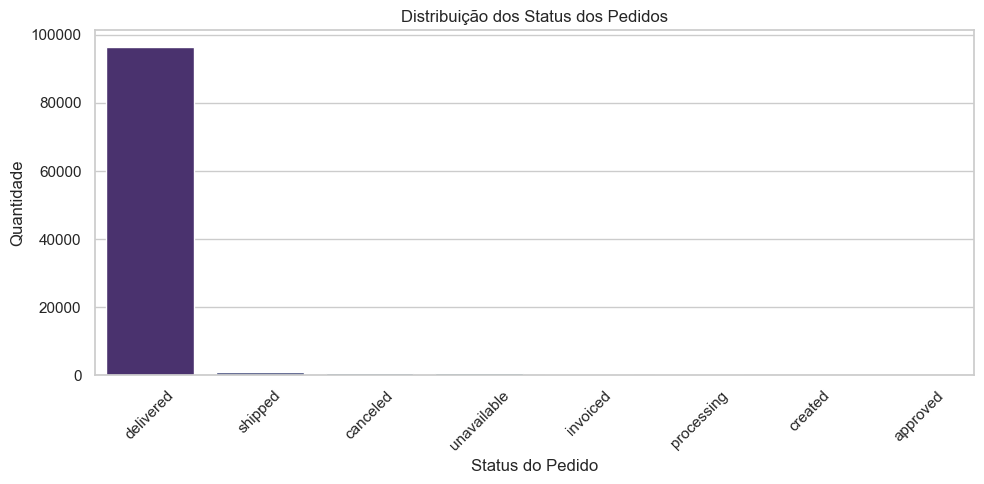

In [8]:
# Gráfico de barras do status dos pedidos
plt.figure(figsize=(10, 5))
sns.barplot(x=status_counts.index, y=status_counts.values, palette="viridis")
plt.title('Distribuição dos Status dos Pedidos')
plt.xlabel('Status do Pedido')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## ⏱️ Cálculo do Tempo de Entrega

Convertendo as colunas de data e calculando o tempo de entrega de cada pedido (em dias).


In [10]:
# Converte as colunas de data
df_pedidos['order_purchase_timestamp'] = pd.to_datetime(df_pedidos['order_purchase_timestamp'])
df_pedidos['order_delivered_customer_date'] = pd.to_datetime(df_pedidos['order_delivered_customer_date'])

# Calcula o tempo de entrega (em dias)
df_pedidos['tempo_entrega'] = (df_pedidos['order_delivered_customer_date'] - df_pedidos['order_purchase_timestamp']).dt.days

# Mostra os primeiros resultados
df_pedidos[['order_purchase_timestamp', 'order_delivered_customer_date', 'tempo_entrega']].head()


,order_purchase_timestamp,order_delivered_customer_date,tempo_entrega
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0


## 📈 Gráfico da Distribuição do Tempo de Entrega

Visualizamos a quantidade de pedidos por tempo de entrega usando um histograma com curva de densidade.


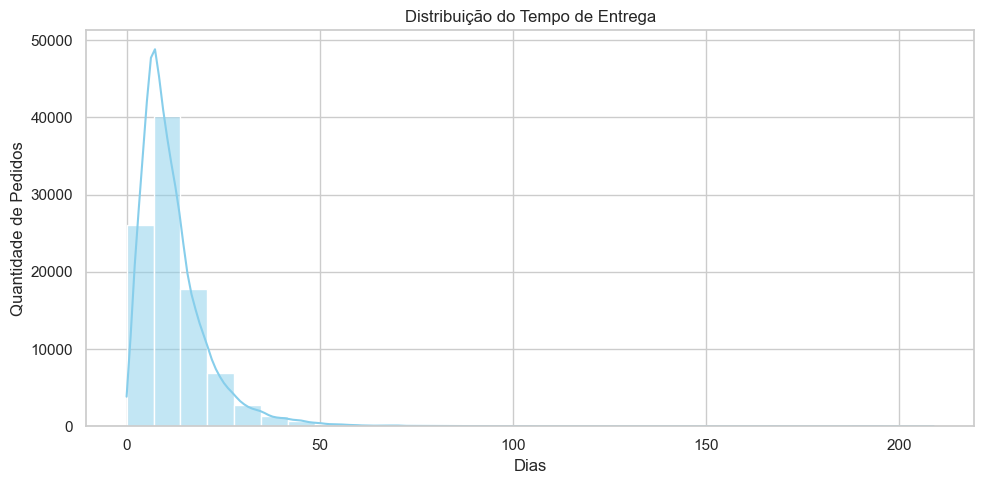

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df_pedidos['tempo_entrega'].dropna(), bins=30, kde=True, color="skyblue")
plt.title('Distribuição do Tempo de Entrega')
plt.xlabel('Dias')
plt.ylabel('Quantidade de Pedidos')
plt.tight_layout()
plt.show()


## 📌 Estatísticas Descritivas do Tempo de Entrega

Aqui analisamos os valores mínimo, máximo, média, mediana e outros dados estatísticos do tempo de entrega.


In [14]:
# Estatísticas gerais
df_pedidos['tempo_entrega'].describe()


count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: tempo_entrega, dtype: float64